# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

Primeramente cargamos los datos del _xlsx_, haciendo los cambios necesarios para una lectura limpia.

In [ ]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'data/online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


Y tras ello, se va a guardar esta lectura para futuras lecturas, sin la necesidad de volver a leer el _xlsx_.

In [ ]:
df.to_pickle('data/online_retail.pkl')

In [2]:
df = pd.read_pickle('data/online_retail.pkl')

## 2. Primera inspección

Ahora se va a ser una pequeña lectura de como están los datos y si se han cargado correctamente. 

In [3]:
df.head(10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [4]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Según las descripción de nuestro _dataset_, el _Customer ID_ debe de ser tipo string (object). Por lo tanto se va a modificar para que sea así sin modificar, si tuviera, los nulos a una forma valida. También se va a asegurar que el _Invoice_, _StockCode_, _Description_ y _Country_ sean también String, por las especificaciones de cada columna.

In [5]:
df['Customer ID'] = pd.to_numeric(df['Customer ID'], errors='coerce').astype('Int64').astype('string')
df.Invoice = df.Invoice.astype('string')
df.StockCode = df.StockCode.astype('string')
df.Description = df.Description.astype('string')
df.Country = df.Country.astype('string')
df.dtypes

Invoice        string[python]
StockCode      string[python]
Description    string[python]
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID    string[python]
Country        string[python]
dtype: object

## 3. Calidad de datos

Primeramente vamos a ver si hay duplicados en nuestro _dataset_.

In [6]:
df2 = df[df.duplicated()]
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom


Se ve que existe duplicados en las compras, pero ¿cómo son estos duplicados? Vamos a ver del primer _Invoice_ obtenido.

In [7]:
df_invoice = df[df.Invoice=="489517"]
df_invoice[df_invoice.duplicated(keep=False)].sort_values(by='Description')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom
388,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom


Como se puede ver, la repetición de varios elementos en una misma fecha y con las mismas cantidades se puede entender o que sea una equivocación al pasar por el escáner los productos, o que el usuario o la empleada ha pasado uno a uno los valores, siendo los valores grandes el pack del producto. 

In [8]:
df_no_dups = df.drop_duplicates()

Ahora se verá, si hubiera, la cantidad de nulos y el porcentaje del impacto de la existencia de nulos

In [9]:
df_no_dups.isnull().sum()*100/df.shape[0]

Invoice         0.000000
StockCode       0.000000
Description     0.400517
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.030859
Country         0.000000
dtype: float64

Se puede ver que _Customer ID_ casi tiene un cuarto de sus valores nulos. Esto es una cantidad significativa dentro del _dataset_. Sin embargo, sin tener que hacer análisis más complejos, posiblemente viendo patrones para la identificación de un usuario registrado en esos valores nulos, no es posible hacer esta identificación.\
Esto da lugar a tener dos opciones viables:
* Poner estos usuarios nulos con un valor a 0 u otro indicador que lo identifique. El problema con esta solución es que si se va a realizar un estudio para, por ejemplo, agrupar los tipos de compradores que hay, este usuario interferiría en una cantidad considerable, o que se identifique como un tipo de usuario único.
* Eliminar directamente todas las entradas que tengan el usuario valor nulo. Esta sería la solución más directa si no queremos lidiar con los posibles futuros problemas si se mantuviese.

Para nuestro caso, por ahora la mejor opción sería eliminar esos registros.

A continuación se va a analizar todas las columnas numérica para hacer una comprobación de que no haya valores negativos o de valor 0 que no tenga sentido en nuestra lógica. Primeramente se va a analizar para la columna de _Price_. En una primera instancia, tener precios negativos podría ser lógico por una devolución u por otras razones para la contabilidad. Igualmente se va a ver sí de primeras tendría ese sentido descrito anteriormente.

In [10]:
df_no_dups[df_no_dups.Price < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,<NA>,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,<NA>,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,<NA>,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom


Se puede ver que en el _dataset_ hay valores negativos, de los cuales en total de las miles de entradas, solo existen 5 entradas. Dada la descripción que nos da para esas entradas, son instancias en la que probablemente un cliente no es capaz de devolver una deuda. En este sentido, que haya valores negativos indicando que es una perdida de capital para la tienda tiene lógica para la contabilidad.

In [11]:
df_no_dups[df_no_dups.StockCode=='B']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,<NA>,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,<NA>,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,<NA>,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,<NA>,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom


Explorando más a detalle este código propio, sigue siendo entradas relacionadas con la contabilidad. También se puede ver que incluso ha habido errores al hacer este ajustes. Pero lo más importante es que estas entradas no tienen _Customer ID_ validos. Por lo tanto, estas entradas se eliminarían si eliminásemos todas las entradas con ese valor a nulo.

Esto nos puede dar otra solución: Rellenar los _Customer ID_ nulos con identificadores únicos dependiendo del código del stock al que están relacionados. De esta forma, si hubiera entradas para transacciones internas de negocio, no se perderían. Otra forma sería de hacer un _Hash_ con el _StockCode_ y el _Country_ por si estas transacciones internas también dependan de la ubicación del negocio.\
Aun así, seguimos sin poder hacer una trazabilidad para los que sean compras normales. Se podría hacer un filtrado para esto. Por lo general, parece ser que los códigos que sean menor de 5 caracteres o que solo sean letras, son las que pertenece a transacciones interna u operativas normales del negocio, como es el Descuento.

Sin embargo, hay que tener en cuenta que este código de normal está compuesto por solamente un número de 5 dígitos. Por lo tanto, habría que igualmente impugnar estas entradas que tengan códigos no estandarizados. 

In [12]:
df_no_dups[(df_no_dups['Customer ID'].isna()) & ((df_no_dups.StockCode.str.len() <= 4) | (df_no_dups.StockCode.str.isalpha()==True))][['StockCode','Description']].drop_duplicates()

,StockCode,Description
2379,DOT,DOTCOM POSTAGE
2697,M,Manual
11553,POST,POSTAGE
14481,C2,CARRIAGE
29414,D,Discount
32207,C2,<NA>
70975,ADJUST,Adjustment by john on 26/01/2010 16
71063,ADJUST,Adjustment by john on 26/01/2010 17
80231,DCGSSGIRL,<NA>
83304,GIFT,<NA>


También hay que va la otra columna numérica, _Quantity_. Por una parte, tendría sentido que haya una cantidad negativa si lo que se quiere indicar que sea una cancelación o una gestión de inventario. Por otra parte, es posible que pueda interferir en un análisis futuro. 

In [13]:
df_no_dups[df_no_dups.Quantity < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [14]:
df_no_dups[df_no_dups.Invoice == "C489449"]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321,Australia


In [15]:
df_no_dups[(df_no_dups['Customer ID']=="16321") & (df_no_dups.StockCode=="22087")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
187,489450,22087,PAPER BUNTING WHITE LACE,12,2009-12-01 10:36:00,2.95,16321,Australia
590070,541657,22087,PAPER BUNTING WHITE LACE,6,2011-01-20 12:11:00,2.95,16321,Australia
609731,543372,22087,PAPER BUNTING WHITE LACE,18,2011-02-07 15:01:00,2.95,16321,Australia
609761,C543375,22087,PAPER BUNTING WHITE LACE,-18,2011-02-07 15:09:00,2.95,16321,Australia
609763,543376,22087,PAPER BUNTING WHITE LACE,18,2011-02-07 15:10:00,2.95,16321,Australia


Sin embargo, si nos fijamos en la evolución de uno de los productos para ese usuario, tiene sentido que sea que haya devuelto ese producto. Hay que destacar que aparece que un usuario ha devuelto un producto sin haberlo comprado anteriormente. Es posible que sea un error en la introducción de los datos.

Si volvemos a fijarnos en la tabla donde se ve las entradas con las cantidades negativas, se ve que casi todos sus valores empiezan con la 'C'. Estas entradas son las cancelaciones hecha por los usuarios. ¿Pero que pasa con las que no lo sean?

In [16]:
display(df_no_dups[(df_no_dups.Quantity < 0) & (df_no_dups.Invoice.str[0]!='C')])
print('-'*100)
display(df_no_dups[(df_no_dups.Quantity < 0) & (df_no_dups.Invoice.str[0]!='C') & (df_no_dups.Price!=0)])
print('-'*100)
print(df_no_dups[(df_no_dups.Quantity < 0) & (df_no_dups.Invoice.str[0]!='C')]['Description'].unique())


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,<NA>,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,<NA>,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,<NA>,United Kingdom
470,489521,21646,<NA>,-50,2009-12-01 11:44:00,0.0,<NA>,United Kingdom
3114,489655,20683,<NA>,-44,2009-12-01 17:26:00,0.0,<NA>,United Kingdom
...,...,...,...,...,...,...,...,...
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,<NA>,United Kingdom
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,<NA>,United Kingdom
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,<NA>,United Kingdom
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,<NA>,United Kingdom


----------------------------------------------------------------------------------------------------


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


----------------------------------------------------------------------------------------------------
<StringArray>
[   '85123a mixed',           'short',     '21733 mixed',              <NA>,
            'lost',         'damages', 'invcd as 84879?',    'sold as gold',
           '21494',           'lost?',
 ...
      '?? missing',      'wet pallet',     '????missing',      '???missing',
            'wet?',          'lost??',             '???',       'wet boxes',
 '????damages????',        'mixed up']
Length: 223, dtype: string


Por lo que se ve, las que no son cancelaciones o son operaciones internas corrigiendo errores en el inventario o dando a declarar la perdida y destrozo del stock. Hasta hay veces que no se pone que operación han hecho.

Tras este análisis, como nuestro objetivo es el modelar la probabilidad de los clientes para una recompra, tener entradas que sean de operaciones internas no nos va a servir de mucho. Si quisiéramos ver la evolución de la tienda o cómo nos afecta estas pérdidas del material, tendría sentido mantenerlas. Como se ha visto anteriormente, estas operaciones internas no contienen normalmente un ID de cliente. Por lo tanto, y como se había visto al principio del apartado, lo mejor va a ser eliminar todas las entradas que no tengan ese ID.\
En cuanto a las partes de cantidad y precio negativo, en este último no hay problema ya que se eliminara junto a la eliminación de las entradas sin ID. En cambio, para las cantidades negativas sigue teniendo sentido su existencia, ya que nos indica en el apartado de la recompra si un usuario va a devolver el producto comprados, o al final no lo va a comprar.\
Por ultimo, también se va a eliminar las entradas en donde no cumplan que tengan sólo 5 dígitos en su _StockCode_.

In [17]:
df_clean = df_no_dups[(df_no_dups.StockCode.str.contains(r'\d{5}'))&(df_no_dups.StockCode.str.len()==5)].dropna(subset="Customer ID")

In [18]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


Comprobamos que todo esté correctamente, con sus tipos y sin nulos.

In [19]:
df_clean.isnull().sum()*100/df_clean.shape[0]

Invoice        0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
Price          0.0
Customer ID    0.0
Country        0.0
dtype: float64

In [20]:
df_clean.duplicated().sum()

np.int64(0)

In [21]:
df_clean.dtypes

Invoice        string[python]
StockCode      string[python]
Description    string[python]
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID    string[python]
Country        string[python]
dtype: object

## 4. Estadísticas descriptivas

In [22]:
df_clean.describe(include=[np.number])

,Quantity,Price
count,706085.000000,706085.000000
mean,12.722451,2.974080
std,202.250924,4.604864
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,649.500000


In [23]:
df_clean.describe(exclude=[np.number])

,Invoice,StockCode,Description,InvoiceDate,Customer ID,Country
count,706085,706085,706085,706085,706085,706085
unique,42751,3331,3903,NaN,5837,41
top,579196,22423,REGENCY CAKESTAND 3 TIER,NaN,17841,United Kingdom
freq,485,3678,3678,NaN,10895,633355
mean,NaN,NaN,NaN,2011-01-11 07:57:54.331107584,NaN,NaN
min,NaN,NaN,NaN,2009-12-01 07:45:00,NaN,NaN
25%,NaN,NaN,NaN,2010-07-16 16:10:00,NaN,NaN
50%,NaN,NaN,NaN,2010-12-10 11:01:00,NaN,NaN
75%,NaN,NaN,NaN,2011-08-09 16:27:00,NaN,NaN
max,NaN,NaN,NaN,2011-12-09 12:50:00,NaN,NaN


## 5. Visualizaciones

A continuación se va a ha hacer las representaciones de las variables numéricas, para ver si hay outliers.

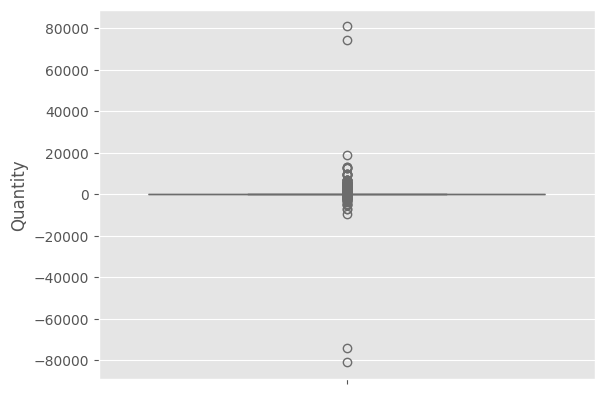

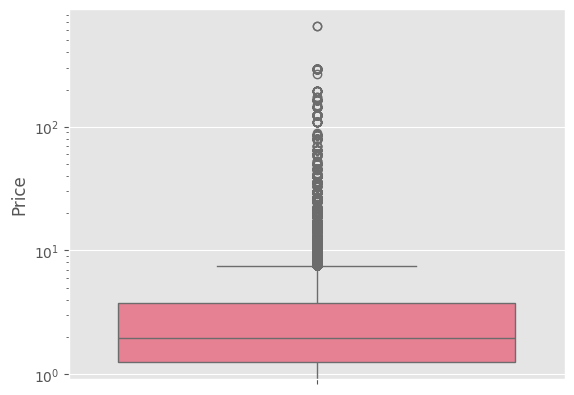

In [24]:
plt.figure()
sns.boxplot(df_clean.Quantity)
plt.show()
plt.figure()
sns.boxplot(df_clean.Price)
plt.yscale('log')
plt.show()

Como se puede ver, hay _outliers_ en ambas columnas, por lo tanto se tendría que realizar una eliminación de ellas. Antes de realizar uno de los métodos para la eliminación de _outliers_ se va a revisar que tipo de distribución siguen.

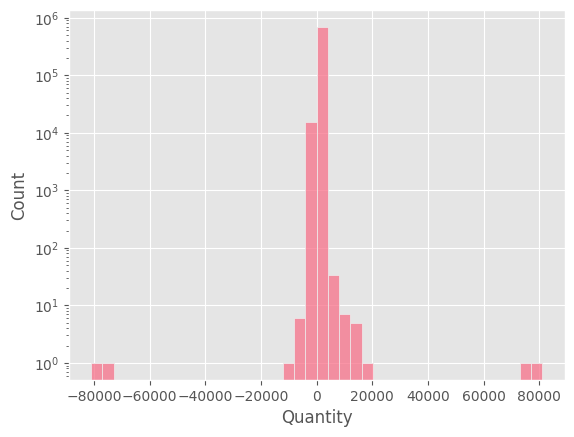

In [25]:
sns.histplot(df_clean['Quantity'], bins=40)
plt.yscale('log')

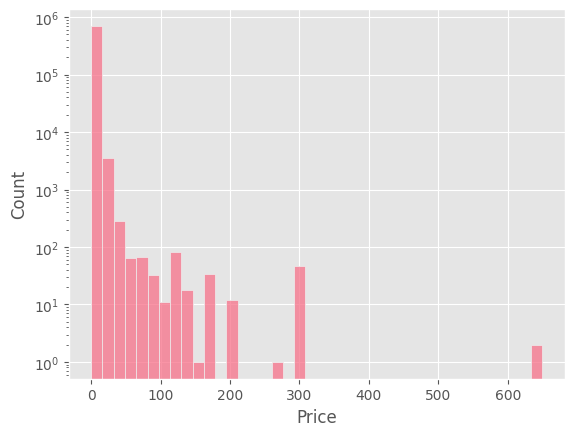

In [26]:
sns.histplot(df_clean['Price'], bins=40)
plt.yscale('log')

Se puede ver que para la columna de _Quantity_ sigue una distribución normal, por lo que se puede usar el intervalo de IQR para su eliminación. Sin embargo _Price_ no sigue una distribución normal, por lo que el mejor método sera eliminar lo que este fuera del intercuartil 5%.

In [27]:
IQ1 = df_clean.Quantity.quantile(0.25)
IQ3 = df_clean.Quantity.quantile(0.75)
IQR = IQ3 -IQ1
bounds = (IQ1-1.5*IQR,IQ3+1.5*IQR)
df_clean[df_clean.Quantity.between(*bounds)].shape

(659200, 8)

In [28]:
IQ05 = df_clean.Price.quantile(0.05)
IQ95 = df_clean.Price.quantile(0.95)
bound_price = (IQ05, IQ95)
df_clean[df_clean.Price.between(*bound_price)].shape

(650829, 8)

In [29]:
df_final = df_clean[(df_clean.Quantity.between(*bounds))&(df_clean.Price.between(*bound_price))]

Tras la limpieza de _outliers_, se realiza otra vez las representaciones para ver si quedan _outliers_.

In [30]:
df_final.describe(include=[np.number])

,Quantity,Price
count,612856.000000,612856.000000
mean,6.953932,2.582301
std,6.658548,1.998637
min,-13.000000,0.420000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.350000
max,27.000000,8.500000


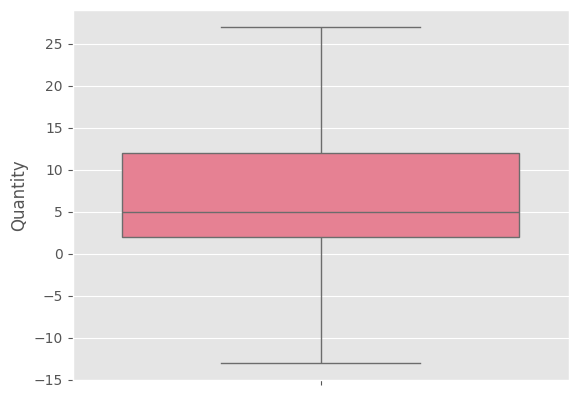

In [31]:
plt.figure()
sns.boxplot(df_final.Quantity)
plt.show()

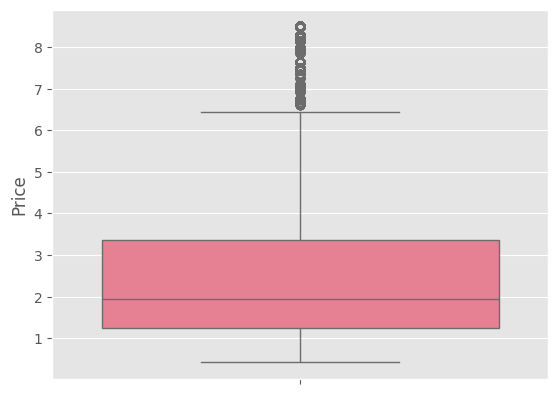

In [32]:
plt.figure()
sns.boxplot(df_final.Price)
plt.show()

Como se puede ver, el la parte de _Quantity_ ya no existen _outliers_, pero sí en _Price_. Debido a que _price_ no es una distribución normal, se va a mantener estos _outliers_.

A continuación se va a ver como de relacionado están los elementos del _dataset_.

<Axes: >

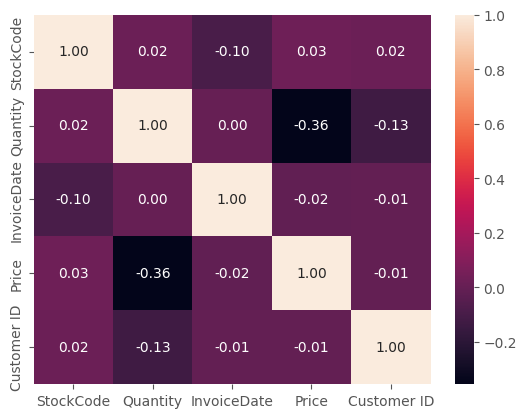

In [33]:
sns.heatmap(df_final.drop(columns=['Invoice','Description','Country']).corr(), annot=True, fmt=".2f")

Como se ve en la gráfica, hay muy poca o nula correlación entre los valores, menos para la cantidad y el precio del producto. Tiene sentido que ambos estén algo relacionados ya que un cliente para comprar un producto, lo hace en x cantidades y en y precio. También es que en varios productos se considera también cada uno de los elementos dentro de un pack. Por lo tanto, si se repite en gran cantidad el hacer la cuenta con el pack de un producto contando como si fuera cada elemento, es normal que aumente por esta parte la correlación.

Por último se va a realizar unas gráficas para el análisis en vista de negocio.

In [34]:
df_final["Total"] = df_final.Quantity * df_final.Price
df_final["Year"] = df_final.InvoiceDate.dt.year
df_final["Date"] = df_final.InvoiceDate.dt.date
df_final["MonthYear"] = df_final.InvoiceDate.dt.to_period("M").astype(str)
df_final["Devolution"] = df_final.Invoice.apply(lambda x: 1 if x[0]=='C' else 0)

C:\Users\franc\AppData\Local\Temp\ipykernel_31272\2299083935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Total"] = df_final.Quantity * df_final.Price
C:\Users\franc\AppData\Local\Temp\ipykernel_31272\2299083935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Year"] = df_final.InvoiceDate.dt.year
C:\Users\franc\AppData\Local\Temp\ipykernel_31272\2299083935.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

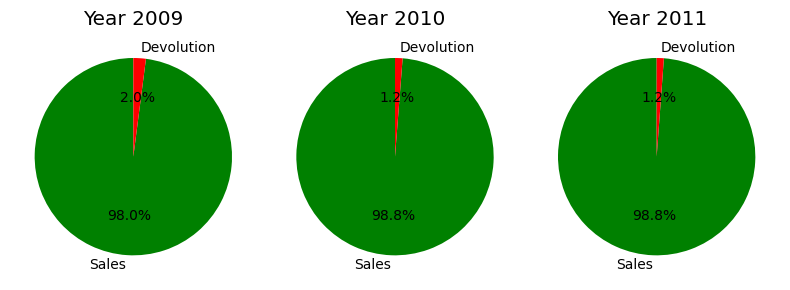

In [35]:
df_plot = df_final.groupby(['Year','Devolution'], as_index=False).agg(Total=('Total',lambda x: x.abs().sum()))
years = df_plot.Year.unique()
fig, axes = plt.subplots(1, len(years), figsize=(8,8))
for ax, year in zip(axes, years):
    year_data = df_plot[df_plot['Year'] == year]
    ax.pie(
        year_data['Total'],
        labels=['Sales','Devolution'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['g','r']
    )
    ax.set_title(f"Year {year}")

plt.tight_layout()
plt.show()

De primeras, podemos ver que las devoluciones son una parte muy pequeña del negocio, de tal manera que los clientes apenas devuelven los productos. También que es algo constante el ratio de devolución, siendo 2009 el año con más devoluciones realizadas.

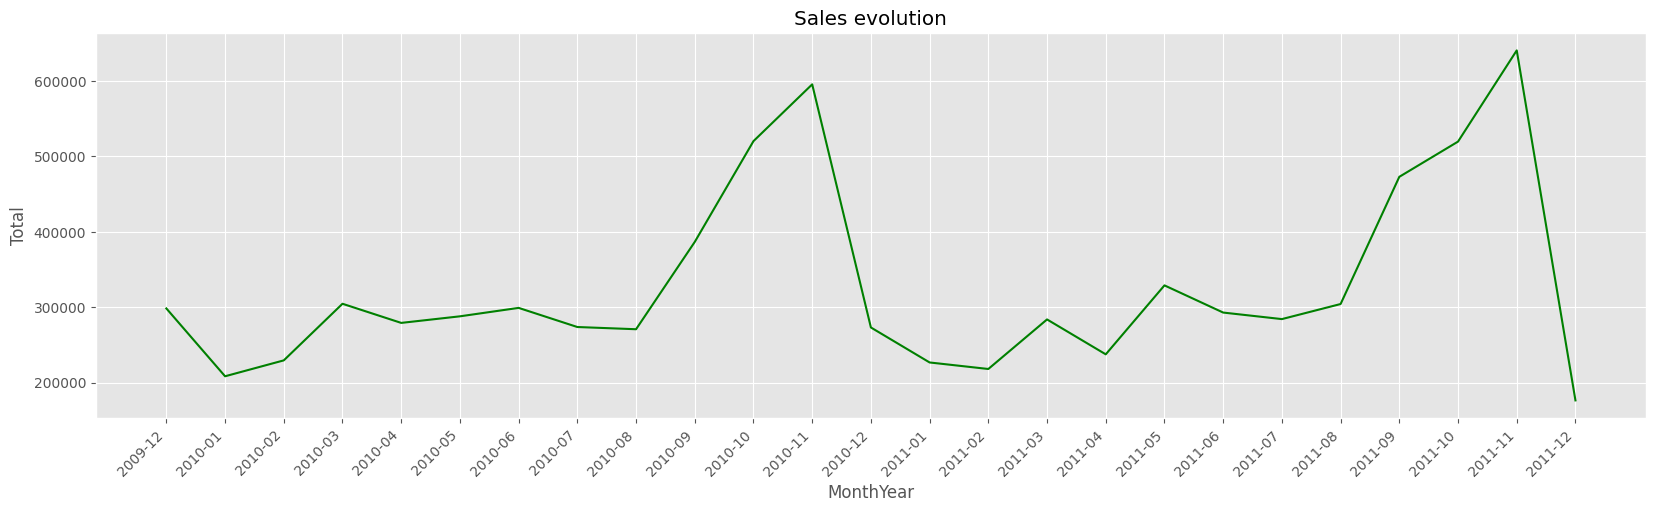

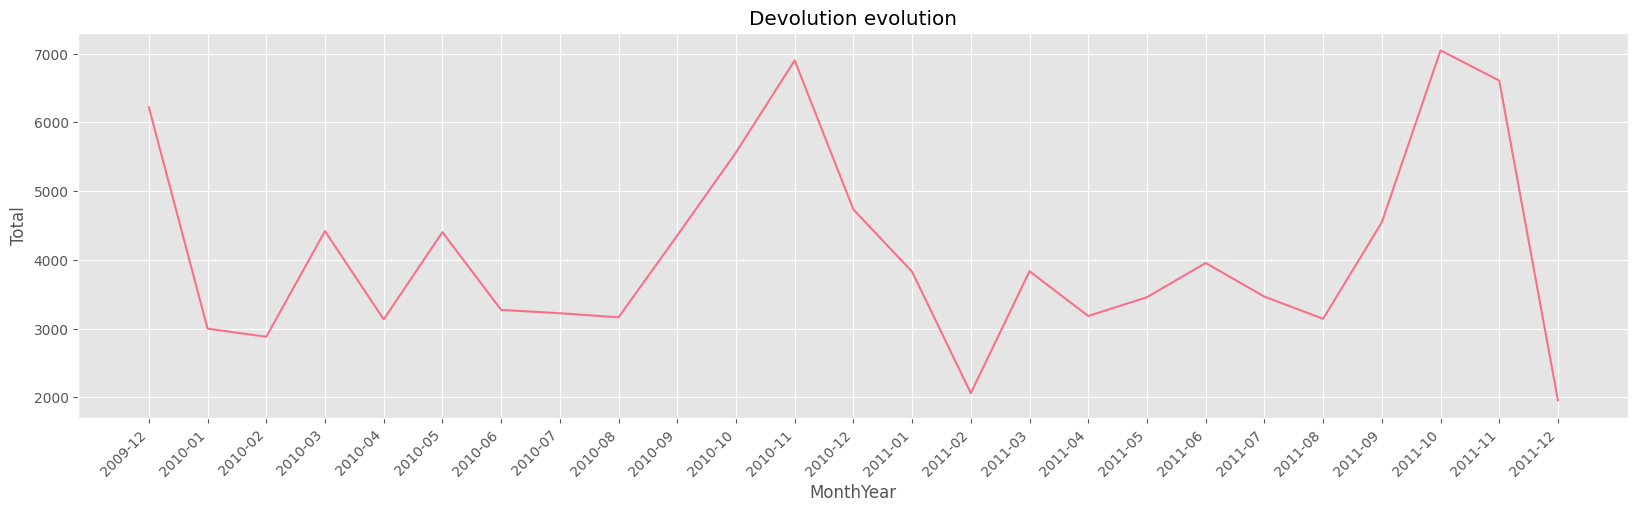

In [36]:
df_plot = df_final.groupby(['MonthYear','Devolution'], as_index=False).agg(Total=('Total',lambda x: x.abs().sum()))
plt.figure(figsize=(20,5))
sns.lineplot(x='MonthYear', y='Total', data=df_plot[df_plot.Devolution==0],color='green')
plt.xticks(rotation=45, ha="right")
plt.title("Sales evolution")
plt.show()
plt.figure(figsize=(20,5))
sns.lineplot(x='MonthYear', y='Total',  data=df_plot[df_plot.Devolution==1])
plt.xticks(rotation=45, ha="right")
plt.title("Devolution evolution")
plt.show()

Realizando una gráfica en el tiempo, se puede ver que tanto las compras como las devoluciones, siguen una estacionalidad muy notable. Esta estacionalidad es muy común en el sector de las tiendas, en la que durante los meses cercanos a Navidad aumenta en gran cantidad las ventas. De misma manera, es normal que las devoluciones sean también en esas fechas, ya que también o se compra en mayor cantidad o ya no lo quieren o porque sale defectuoso el producto.

## 6. Agrupación por cliente (Customer ID)

Por cada cliente se va a calcular lo siguiente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [37]:
df_final["Total"] = df_final.Quantity * df_final.Price
df_final["Year"] = df_final.InvoiceDate.dt.year
agg_df = df_final.groupby(['Customer ID','Year','Invoice'], as_index=False).agg(TotalSales=('Total','sum')).groupby(['Customer ID','Year'], as_index=False).agg(TotalSales = ('TotalSales', 'sum'), NumberSales = ('Invoice', 'count'), AvgSale = ('TotalSales','mean'))
agg_df

C:\Users\franc\AppData\Local\Temp\ipykernel_31272\1672380885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Total"] = df_final.Quantity * df_final.Price
C:\Users\franc\AppData\Local\Temp\ipykernel_31272\1672380885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Year"] = df_final.InvoiceDate.dt.year


,Customer ID,Year,TotalSales,NumberSales,AvgSale
0,12346,2010,144.02,2,72.010000
1,12347,2010,896.10,2,448.050000
2,12347,2011,2502.14,6,417.023333
3,12348,2010,232.20,2,116.100000
4,12348,2011,37.40,2,18.700000
...,...,...,...,...,...
9107,18286,2009,127.80,1,127.800000
9108,18286,2010,700.49,1,700.490000
9109,18287,2009,-5.10,1,-5.100000
9110,18287,2010,1105.66,4,276.415000


Se puede ver que tenemos unos 5940 usuarios distintos en nuestro _dataset_, de los cuales se pueden analizar en futuras pruebas para ver sus tendencias.

## 7. Modelo: probabilidad de recompra

Con los datos anteriores, se va a realizar un modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte. Para ello se va a realizar los siguientes pasos:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

Primeramente vamos a obtener de nuevo el _dataset_ marcando una fecha de corte. Con esa fecha de corte se divide en dos _datasets_, los cuales uno indicara los datos necesarios antes de esa fecha de corte, y si han hecho la recompra en el de después del corte. Se ha elegido como fecha de corte un año anterior a la fecha ultima que aparece en el _dataset_ original.

In [38]:
cutoff_date = np.datetime64('2010-12-09')
df_cutoff_before = df_final[df_final.InvoiceDate < cutoff_date]
df_cutoff_after = df_final[df_final.InvoiceDate >= cutoff_date]
df_cutoff_before['UntilCutoff'] = ((cutoff_date - df_cutoff_before.InvoiceDate) / np.timedelta64(1, 'D')).astype('int')
before_df = df_cutoff_before.groupby(['Customer ID','Invoice'], as_index=False).agg(TotalSales=('Total','sum'),DaySinceSale = ('UntilCutoff', 'min'), Country = ('Country', 'min')).groupby(['Customer ID'], as_index=False).agg(DaySinceSale = ('DaySinceSale', 'min'),TotalSales = ('TotalSales', 'sum'), NumberSales = ('Invoice', 'count'), AvgSale = ('TotalSales','mean'), Country = ('Country', 'min'))
after_df = df_cutoff_after[df_cutoff_after.Quantity > 0].groupby('Customer ID',as_index = False).agg(Revisited=('InvoiceDate', lambda x: 1))
df_cutoff = pd.merge(before_df, after_df, on='Customer ID', how='left').fillna(0)
df_cutoff.Revisited = df_cutoff.Revisited.astype(int)
df_cutoff

C:\Users\franc\AppData\Local\Temp\ipykernel_31272\4116894794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cutoff_before['UntilCutoff'] = ((cutoff_date - df_cutoff_before.InvoiceDate) / np.timedelta64(1, 'D')).astype('int')


,Customer ID,DaySinceSale,TotalSales,NumberSales,AvgSale,Country,Revisited
0,12346,163,144.02,2,72.010000,United Kingdom,0
1,12347,1,896.10,2,448.050000,Iceland,1
2,12348,72,179.40,1,179.400000,Finland,1
3,12349,41,1670.19,3,556.730000,Italy,1
4,12351,9,288.18,1,288.180000,Unspecified,0
...,...,...,...,...,...,...,...
4146,18283,16,478.51,6,79.751667,United Kingdom,1
4147,18284,65,266.48,1,266.480000,United Kingdom,0
4148,18285,294,127.20,1,127.200000,United Kingdom,0
4149,18286,110,828.29,2,414.145000,United Kingdom,0


Tras hacer la union de los dos _datasets_, se obtiene otro _dataset_ el cual podemos usar para el entrenamiento. Igualmente, antes de empezar con eso, se va a cambiar la columna de _Country_ a una columna binaria, indicando si el clientes de UK o no. Con ello se podría poner esa columna para hacer una regresión logística.

In [39]:

encoded_df = (df_cutoff.Country.apply(lambda x: int(x == "United Kingdom")))
encoded_df.name = 'FromUK'
df_cutoff_encoded = pd.concat([df_cutoff, encoded_df], axis=1).drop(columns=["Country"])
df_cutoff_encoded

,Customer ID,DaySinceSale,TotalSales,NumberSales,AvgSale,Revisited,FromUK
0,12346,163,144.02,2,72.010000,0,1
1,12347,1,896.10,2,448.050000,1,0
2,12348,72,179.40,1,179.400000,1,0
3,12349,41,1670.19,3,556.730000,1,0
4,12351,9,288.18,1,288.180000,0,0
...,...,...,...,...,...,...,...
4146,18283,16,478.51,6,79.751667,1,1
4147,18284,65,266.48,1,266.480000,0,1
4148,18285,294,127.20,1,127.200000,0,1
4149,18286,110,828.29,2,414.145000,0,1


Con esto obtenemos el _dataset_ definitivo, en el cual nuestra variable objetivo será _Revisited_. Esta variable indica si el cliente ha revisitado la tienda o no.

A continuación veremos que correlación hay entre cada variable, con principal foco a la columna de la variable objetivo.

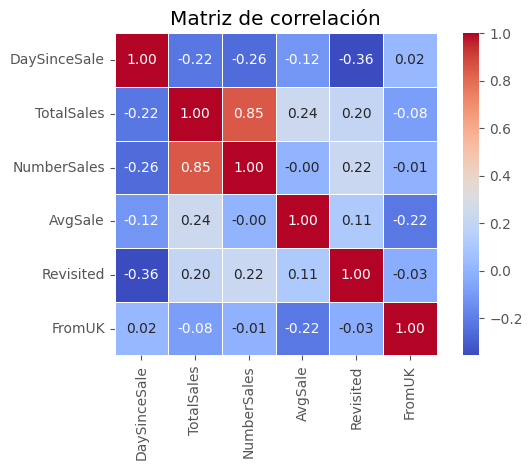

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df_cutoff_encoded.drop(columns='Customer ID').corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


Viendo la correlación, se puede apreciar que hay una gran correlación positiva entre _TotalSales_ y _NumberSales_. Esto tiene sentido si se ve a _AvgSales_, que su calculo se podría dar haciendo una división entre _TotalSales_ y _NumberSales_. Sin embargo, por el momento, se va a dejar esta correlación, ya que no tiene una correlación casi perfecta como para eliminar una de ellas. Por otra parte, viendo la columna de la variable objetivo, se ve que hay el orden, en valores absolutos: _DaySinceSales_ > _NumberSales_ > _TotalSales_ > _AvgSale_ > _FromUK_. Tiene sentido que la mayor sería los días pasados desde la ultima vez que ha ido al negocio hasta el día de corte, ya que un cliente con menos días normalmente quiere decir que vaya a volver antes otra vez que uno que no haya ido durante meses.

In [41]:
df_cutoff_encoded['Revisited'].value_counts()

Revisited
1    2587
0    1564
Name: count, dtype: int64

Viendo la distribución de la variable objetivo, hay un desequilibrio entre las dos variables, pero no es tan grave, siendo más o menos uno la mitad del otro.

Tras este análisis, se va a realizar el entrenamiento para estos ML: Regresión Logística, Árbol de Decisión y _Random Forest_. Todos ellos para clasificación.

In [42]:
def confusion_matrix(y_test, predictions):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, predictions, labels=[1, 0])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()

def classification_report(y_test, predictions):
    from sklearn.metrics import classification_report
    report = classification_report(y_test,predictions, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(classification_report(y_test,predictions))
    return df_report

    
def ROC_Curve (y_test, predictions):
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve

    roc_auc = roc_auc_score(y_test, predictions)
    print(f"ROC-AUC: {roc_auc:.2f}")

    fpr, tpr, thresholds = roc_curve(y_test, predictions)

    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    return roc_auc

    
def kappa_y_mcc(y_test, predictions):
    from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
    kappa = cohen_kappa_score(y_test,predictions)
    mcc = matthews_corrcoef(y_test, predictions)
    print('kappa:' ,kappa, 'mcc:', mcc) 
    return kappa, mcc

def metricas(y_test, y_pred, y_pred_proba, tag):
    confusion_matrix(y_test, y_pred)
    df_report = classification_report(y_test, y_pred)
    roc_auc = ROC_Curve(y_test, y_pred_proba)
    kappa, mcc = kappa_y_mcc(y_test, y_pred)
    return tag, roc_auc, df_report.loc['1', 'precision'], df_report.loc['1', 'recall'], df_report.loc['1', 'f1-score'],  df_report.loc['accuracy', 'f1-score'], kappa, mcc

comparador = pd.DataFrame(columns=['Técnica', 'AUC', 'precision', 'recall','f1-score', 'accuracy','kappa', 'MCC'])

Obtención de las X a entrenar y sus escalados.

In [43]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

X = df_cutoff_encoded.drop(columns=['Customer ID','Revisited'])
X_scaled = MinMaxScaler().fit_transform(X)
y = df_cutoff_encoded['Revisited']

#### Logistic Regression

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)

In [45]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=10000, C=100)
logmodel.fit(X_train,y_train)
predictions = logmodel.predict(X_test)
y_pred_proba = logmodel.predict_proba(X_test)[:, 1]


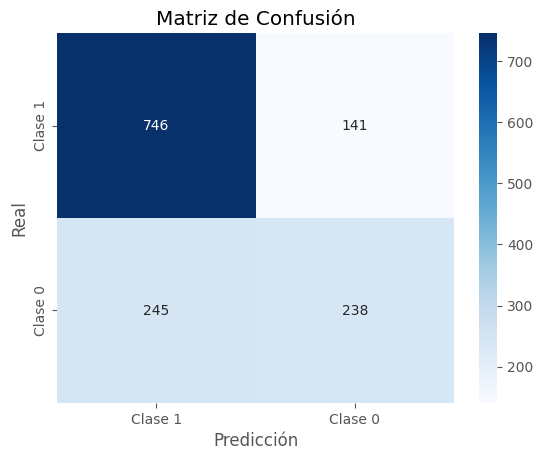

              precision    recall  f1-score   support

           0       0.63      0.49      0.55       483
           1       0.75      0.84      0.79       887

    accuracy                           0.72      1370
   macro avg       0.69      0.67      0.67      1370
weighted avg       0.71      0.72      0.71      1370

ROC-AUC: 0.76


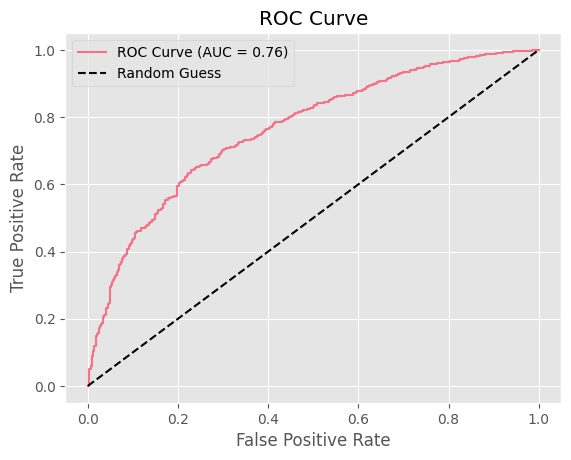

kappa: 0.3510025453286959 mcc: 0.3564949161621062


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Logistic Regression,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495


In [46]:
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Logistic Regression')
comparador

#### Decision Tree Classifier

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

clf = DecisionTreeClassifier(random_state=42, max_features=5, max_depth=6)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

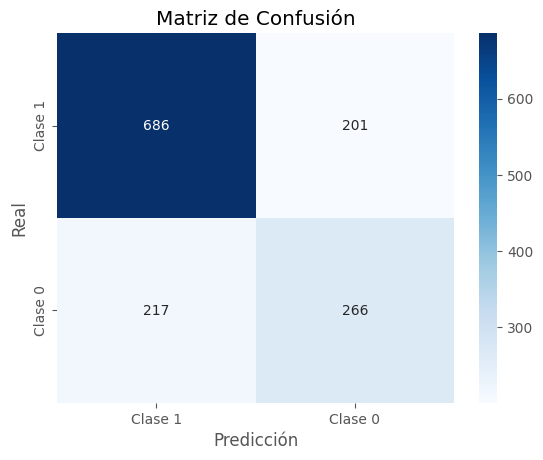

              precision    recall  f1-score   support

           0       0.57      0.55      0.56       483
           1       0.76      0.77      0.77       887

    accuracy                           0.69      1370
   macro avg       0.66      0.66      0.66      1370
weighted avg       0.69      0.69      0.69      1370

ROC-AUC: 0.74


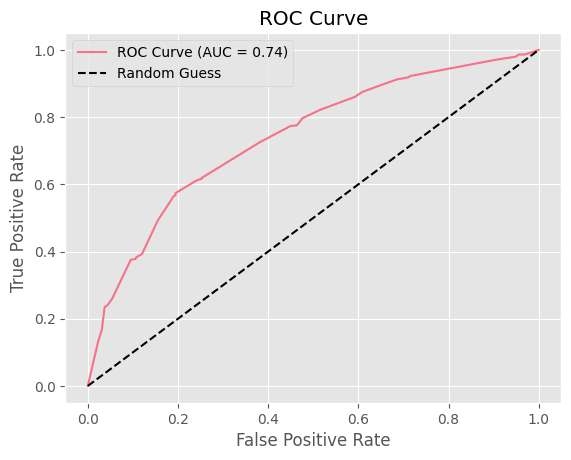

kappa: 0.3265818259644534 mcc: 0.32669037740051116


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Logistic Regression,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495
1,Decision Tree,0.739813,0.759690,0.773393,0.766480,0.694891,0.326582,0.326690


In [48]:
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Decision Tree')
comparador

#### Random Forest Classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

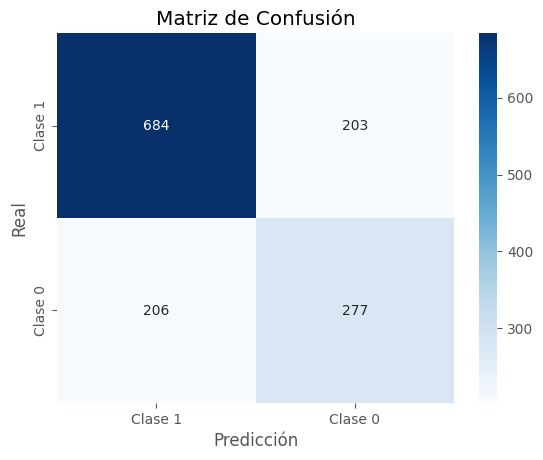

              precision    recall  f1-score   support

           0       0.58      0.57      0.58       483
           1       0.77      0.77      0.77       887

    accuracy                           0.70      1370
   macro avg       0.67      0.67      0.67      1370
weighted avg       0.70      0.70      0.70      1370

ROC-AUC: 0.74


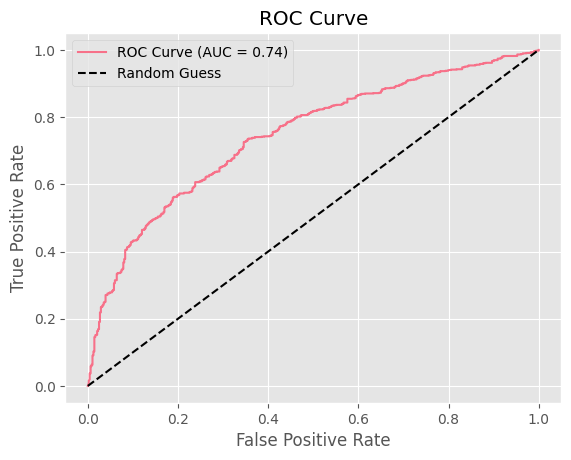

kappa: 0.3451258137278964 mcc: 0.34512979541016


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Logistic Regression,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495
1,Decision Tree,0.739813,0.759690,0.773393,0.766480,0.694891,0.326582,0.326690
2,Random Forest,0.744221,0.768539,0.771139,0.769837,0.701460,0.345126,0.345130


In [50]:
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Random Forest')
comparador

### Búsqueda de hiperparámetros
Con Optuna, a continuación se va a hacer la búsqueda de hiperparámetros para los ML del Árbol de Decisión y la Regresión Logística.


#### Decision Tree Classifier Optuna

In [51]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'max_features' : trial.suggest_int('max_features', 1, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'criterion': trial.suggest_categorical('criterion',["entropy", "gini"])
    }

    model = DecisionTreeClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)

    return auc

c:\Users\franc\Data Science\Machine-Learning\Trabajo final\.venvML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

print(f"Mejores parámetros: {study.best_params}")
print(f"Mejor AUC obtenido: {study.best_value:.4f}")

[I 2026-06-07 23:13:50,943] A new study created in memory with name: no-name-4bf2a309-008a-4dd5-ad34-4af22fe2ba60
[I 2026-06-07 23:13:50,952] Trial 0 finished with value: 0.7544669845782537 and parameters: {'max_depth': 4, 'max_features': 10, 'min_samples_leaf': 8, 'min_samples_split': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7544669845782537.
[I 2026-06-07 23:13:50,959] Trial 1 finished with value: 0.6838110176672012 and parameters: {'max_depth': 1, 'max_features': 9, 'min_samples_leaf': 7, 'min_samples_split': 8, 'criterion': 'gini'}. Best is trial 0 with value: 0.7544669845782537.
[I 2026-06-07 23:13:50,967] Trial 2 finished with value: 0.6980038326786036 and parameters: {'max_depth': 9, 'max_features': 3, 'min_samples_leaf': 2, 'min_samples_split': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.7544669845782537.
[I 2026-06-07 23:13:50,975] Trial 3 finished with value: 0.7501884828241382 and parameters: {'max_depth': 5, 'max_features': 3, 'min_samples_leaf':

Mejores parámetros: {'max_depth': 4, 'max_features': 4, 'min_samples_leaf': 6, 'min_samples_split': 10, 'criterion': 'gini'}
Mejor AUC obtenido: 0.7580


In [53]:
best_params = study.best_params
best_model = DecisionTreeClassifier(**best_params)
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

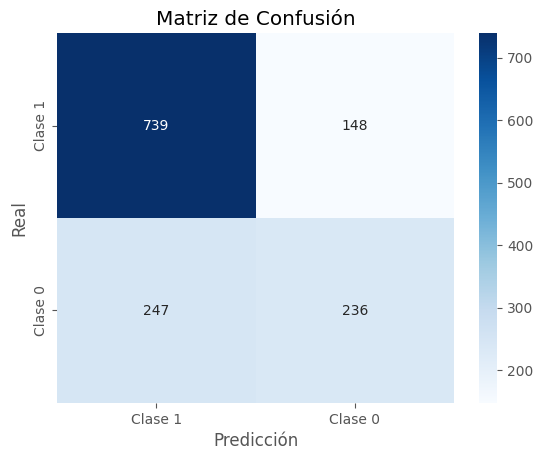

              precision    recall  f1-score   support

           0       0.61      0.49      0.54       483
           1       0.75      0.83      0.79       887

    accuracy                           0.71      1370
   macro avg       0.68      0.66      0.67      1370
weighted avg       0.70      0.71      0.70      1370

ROC-AUC: 0.75


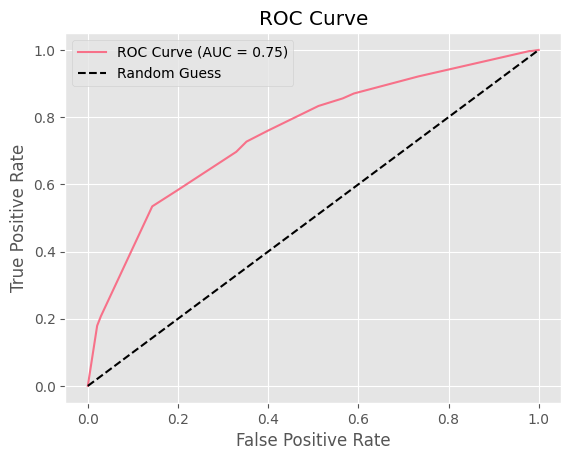

kappa: 0.3375128237146292 mcc: 0.34226384465538656


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Logistic Regression,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495
1,Decision Tree,0.739813,0.759690,0.773393,0.766480,0.694891,0.326582,0.326690
2,Random Forest,0.744221,0.768539,0.771139,0.769837,0.701460,0.345126,0.345130
3,Decision Tree Optuna,0.752757,0.749493,0.833145,0.789108,0.711679,0.337513,0.342264


In [54]:
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Decision Tree Optuna')
comparador

#### Logistic Regression Optuna

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)

In [56]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'max_iter': trial.suggest_categorical('max_iter', [100,1000,10000]),
        'C' : trial.suggest_categorical('C',[0.001,0.01,0.1,1,10,100]),
        'tol': trial.suggest_categorical('tol',[0.001,0.01,0.1,1,10,100]),
    }

    model = LogisticRegression(**params)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)

    return auc

In [57]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print(f"Mejores parámetros: {study.best_params}")
print(f"Mejor AUC obtenido: {study.best_value:.4f}")

[I 2026-06-07 23:13:53,778] A new study created in memory with name: no-name-7d166b1e-da39-4188-8759-18a87b1b72d9
[I 2026-06-07 23:13:53,784] Trial 0 finished with value: 0.5 and parameters: {'max_iter': 1000, 'C': 1, 'tol': 10}. Best is trial 0 with value: 0.5.
[I 2026-06-07 23:13:53,794] Trial 1 finished with value: 0.7637137301859619 and parameters: {'max_iter': 100, 'C': 100, 'tol': 0.001}. Best is trial 1 with value: 0.7637137301859619.
[I 2026-06-07 23:13:53,799] Trial 2 finished with value: 0.5 and parameters: {'max_iter': 100, 'C': 0.1, 'tol': 100}. Best is trial 1 with value: 0.7637137301859619.
[I 2026-06-07 23:13:53,804] Trial 3 finished with value: 0.6881828855261529 and parameters: {'max_iter': 10000, 'C': 100, 'tol': 0.1}. Best is trial 1 with value: 0.7637137301859619.
[I 2026-06-07 23:13:53,812] Trial 4 finished with value: 0.7428464057550868 and parameters: {'max_iter': 1000, 'C': 1, 'tol': 0.001}. Best is trial 1 with value: 0.7637137301859619.
[I 2026-06-07 23:13:53,

Mejores parámetros: {'max_iter': 100, 'C': 100, 'tol': 0.001}
Mejor AUC obtenido: 0.7637


In [58]:
best_params = study.best_params
best_model_lr = LogisticRegression(**best_params)
best_model_lr.fit(X_train, y_train)

predictions = best_model_lr.predict(X_test)
y_pred_proba = best_model_lr.predict_proba(X_test)[:, 1]

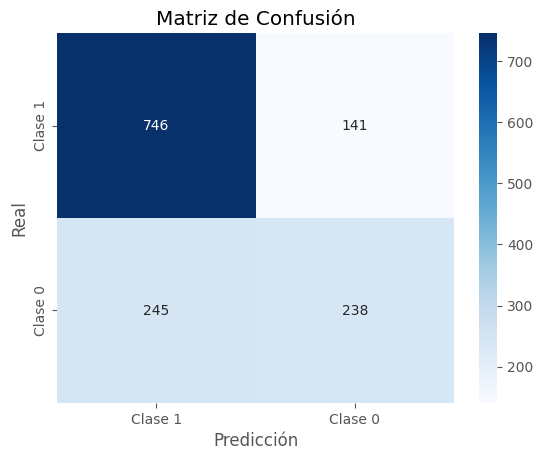

              precision    recall  f1-score   support

           0       0.63      0.49      0.55       483
           1       0.75      0.84      0.79       887

    accuracy                           0.72      1370
   macro avg       0.69      0.67      0.67      1370
weighted avg       0.71      0.72      0.71      1370

ROC-AUC: 0.76


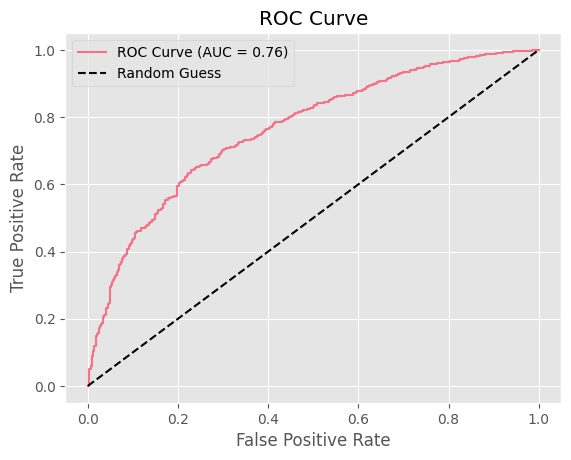

kappa: 0.3510025453286959 mcc: 0.3564949161621062


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Logistic Regression,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495
1,Decision Tree,0.739813,0.759690,0.773393,0.766480,0.694891,0.326582,0.326690
2,Random Forest,0.744221,0.768539,0.771139,0.769837,0.701460,0.345126,0.345130
3,Decision Tree Optuna,0.752757,0.749493,0.833145,0.789108,0.711679,0.337513,0.342264
4,Logistic Regression Optuna,0.763714,0.752775,0.841037,0.794462,0.718248,0.351003,0.356495


In [59]:
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Logistic Regression Optuna')
comparador

Fijándonos en la tabla final, se puede ver que, en cuanto a f1-score y AUC, la Regresión logística sería la mejor, de tal manera que haría un buen compromiso entre los aciertos y los fallos en la predicción. Sin embargo, si nos fijamos en la precisión, el Árbol de Decisión Optimizado es el que mejor resultado da, de tal manera que nos indica con mayor certeza que usuarios de verdad van a volver a la tienda (_revisited_ a 1).\
Como el que se requiere en este caso es uno que tenga un buen valor de AUC, se va a elegir la Regresión Logística

## 8. Modelo: explicabilidad
En esta sección se va a analizar la explicabilidad de los modelos realizados, atendiendo en concreto a la elegida.



### Logistic Regression Optima
Primeramente se va a ver el modelo seleccionado. Para ello se va a obtener los coeficientes de las variables para ver en que cantidad una variable es más importante que las otras.

In [74]:
import pandas as pd
import numpy as np

# Extraer los coeficientes
coeficientes = best_model_lr.coef_[0]  # Es un array 1D si es binario

# Emparejarlos con los nombres de las variables
importancia = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': coeficientes
})

# Ordenarlos por importancia absoluta
importancia['abs'] = np.abs(importancia['coeficiente'])
importancia = importancia.sort_values(by='abs', ascending=False)

print(importancia[['variable', 'coeficiente']])

       variable  coeficiente
2   NumberSales    41.098336
1    TotalSales    21.895356
3       AvgSale     2.179550
0  DaySinceSale    -1.759131
4        FromUK    -0.133317


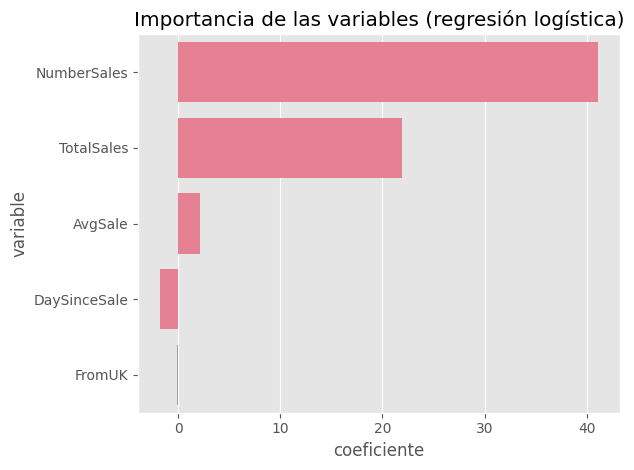

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=importancia, x='coeficiente', y='variable')
plt.title('Importancia de las variables (regresión logística)')
plt.tight_layout()
plt.show()

Así de primeras, el _NumberSales_ y _TotalSales_ son las variables más importantes. Esto nos quiere decir que para un usuario vuelva a comprar en la tienda, va a importar en gran cantidad el gasto general de todas sus compras y las veces que ha comprado. Esto es lógico en el sentido que un cliente que quiera comprar de nuevo sea uno que sea fiel a comprar ahí. También afecta la cantidad que desembolse, pero esa fidelidad es muy importante en cualquier negocio.

C:\Users\franc\AppData\Local\Temp\ipykernel_31272\1632535381.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_aux.groupby('NumberSales')['Revisited'].mean()


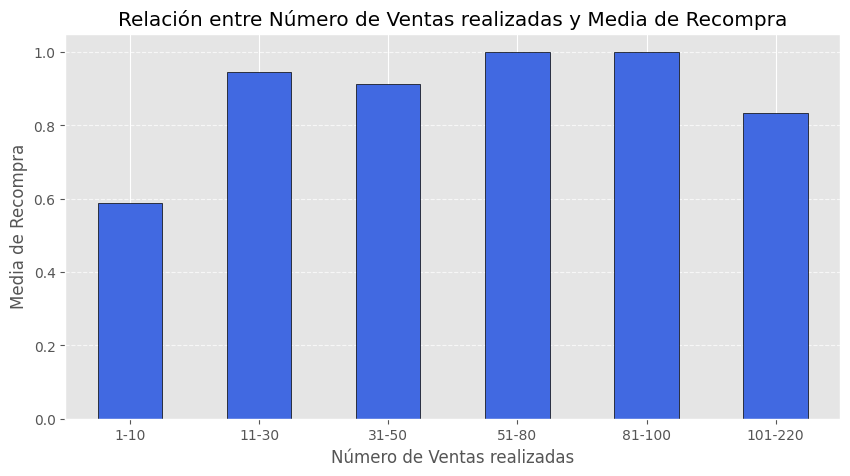

C:\Users\franc\AppData\Local\Temp\ipykernel_31272\1632535381.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_aux.groupby('TotalSales')['Revisited'].mean()


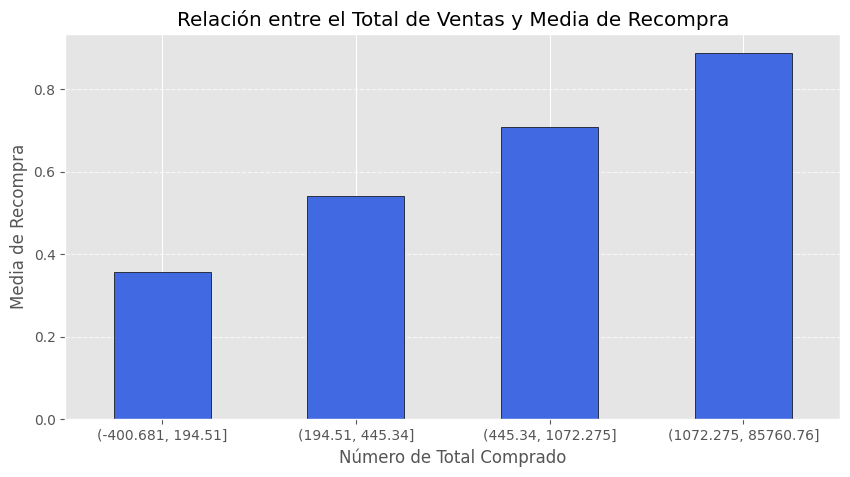

In [61]:
# Calcular la media de 'Exited' para cada número de productos
df_aux = df_cutoff_encoded.copy()
df_aux['TotalSales'] = pd.qcut(df_cutoff_encoded['TotalSales'], q=4)
bins = [1, 10, 30, 50, 80, 100, 220]  # Define bin edges
labels = ['1-10', '11-30', '31-50', '51-80', '81-100', '101-220']
df_aux['NumberSales'] = pd.cut(df_cutoff_encoded['NumberSales'], bins=bins, labels=labels, right=True, include_lowest=True)
df_grouped = df_aux.groupby('NumberSales')['Revisited'].mean()

# Generar gráfico de barras
plt.figure(figsize=(10,5))
df_grouped.plot(kind='bar', color='royalblue', edgecolor='black')

# Personalización del gráfico
plt.xlabel("Número de Ventas realizadas")
plt.ylabel("Media de Recompra")
plt.title("Relación entre Número de Ventas realizadas y Media de Recompra")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

df_grouped = df_aux.groupby('TotalSales')['Revisited'].mean()

# Generar gráfico de barras
plt.figure(figsize=(10,5))
df_grouped.plot(kind='bar', color='royalblue', edgecolor='black')

# Personalización del gráfico
plt.xlabel("Número de Total Comprado")
plt.ylabel("Media de Recompra")
plt.title("Relación entre el Total de Ventas y Media de Recompra")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

Lo de la fidelidad se puede ver perfectamente en la primera gráfica representada que, de forma normal, a partir de las 10 veces compradas hay un aumento de la cantidad de gente que vuelve a comprar. Junto a ello, en la segunda gráfica se puede ver la cantidad total comprado, la cual cuanto más cantidad de dinero se gaste un usuario, más gente son las que vuelve a comprar otra vez en la tienda.

#### Explicaciones de los otros ML
Aquí se va a ver las otras explicaciones de los otros ML mejores que no han sido seleccionados, para ver si con el modelo anterior hubiera algo que se nos escapase.

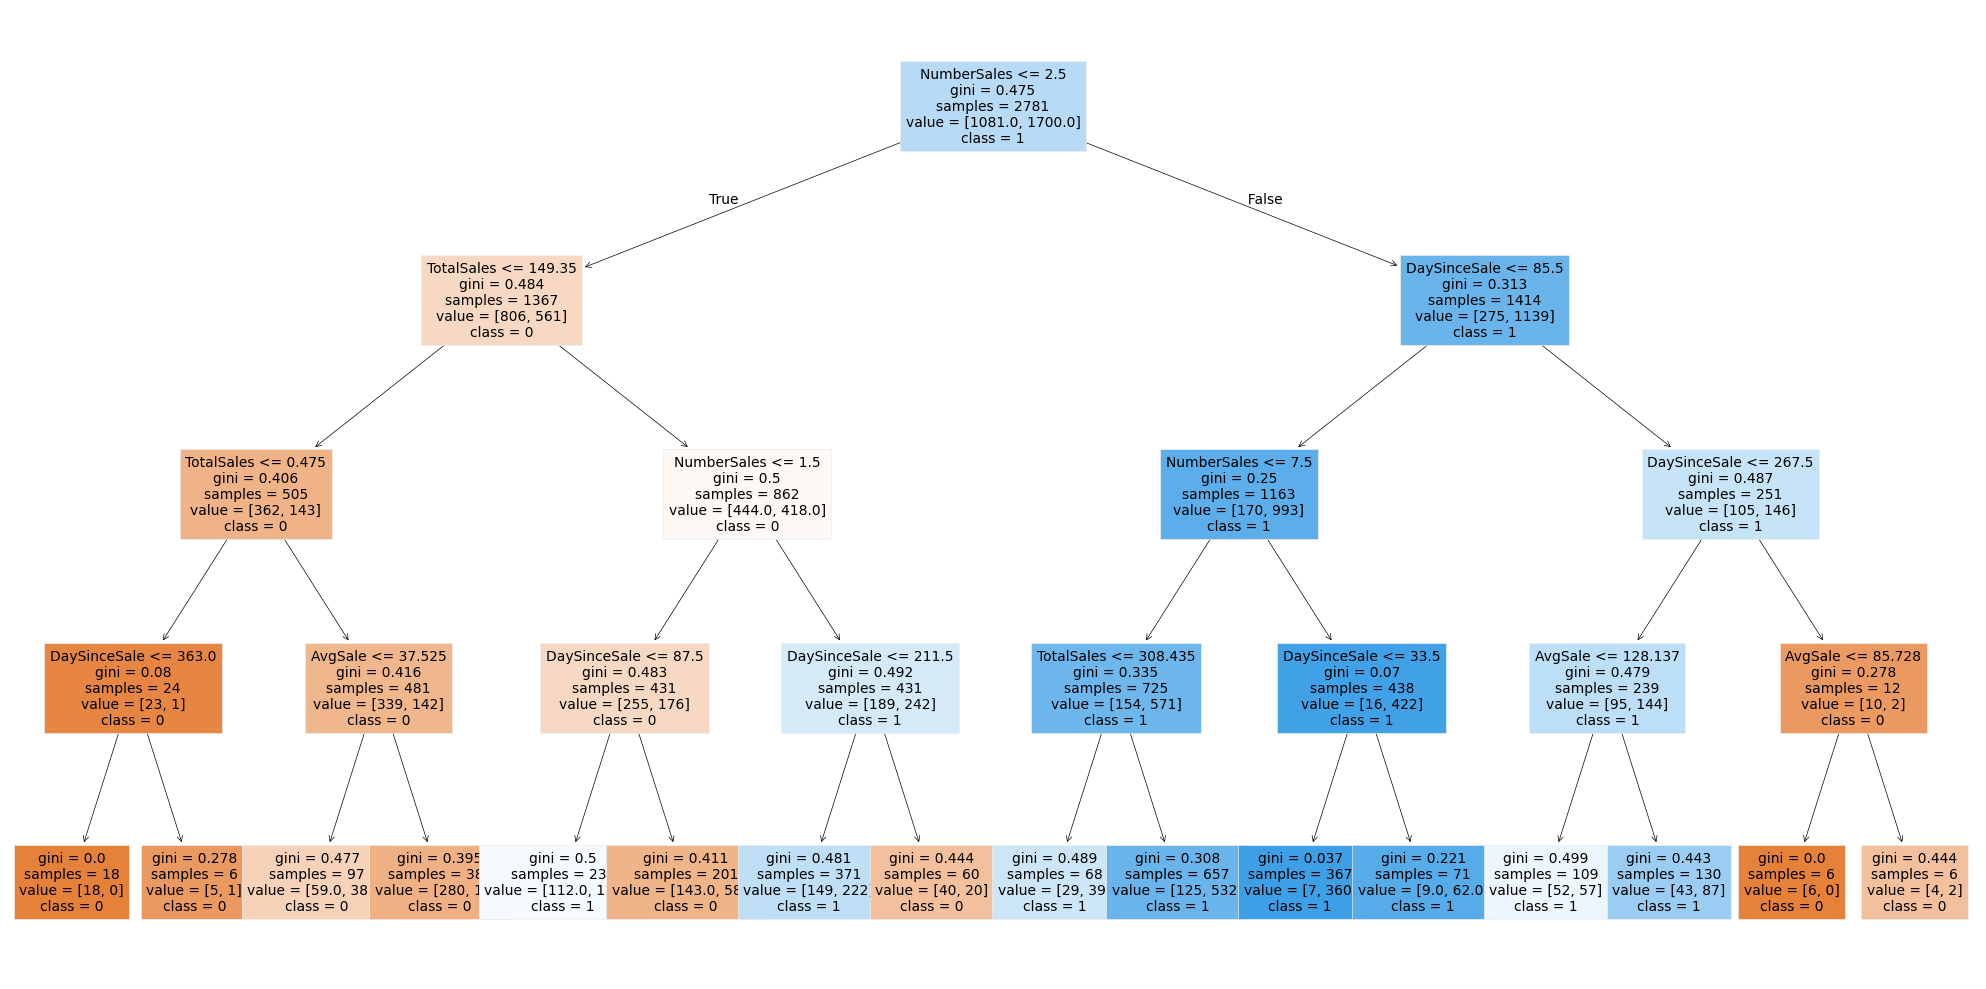

In [63]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(best_model, filled=True, feature_names=X.columns, class_names=best_model.classes_.astype('str'), fontsize=10)
plt.tight_layout()
plt.show()

Para el mejor Árbol de Desición, se llega al mismo razonamiento que en la Regresión Lineal, la cual es más importante el Numero de Venta. Sin embargo, tambien hay un impacto el Total de Ventas y los Días pasados.

In [64]:
import dalex as dx
explicador = dx.Explainer(rf, X, y, label="RandomForest")
importancia = explicador.model_parts(loss_function = '1-auc') 
importancia.plot()

Preparation of a new explainer is initiated

  -> data              : 4151 rows 5 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 4151 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : RandomForest
  -> predict function  : <function yhat_proba_default at 0x0000021C89B98C20> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0164, mean = 0.611, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.012, max = 0.958
  -> model_info        : package sklearn

A new explainer has been created!


En cuanto al _Random Forest_, se ha visto que tiene un mayor impacto los días pasados desde la última compra, seguido del total comprado y el numero de compras realizadas. En este sentido tiene lógica el priorizar los clientes que menos días han pasado sin volver a comprar, y los que mayor cantidad gastan.

In [65]:
explicador.model_profile().plot(facet_ncol=3)

Calculating ceteris paribus: 100%|██████████| 5/5 [00:00<00:00, 14.74it/s]


Sin embargo, si se analiza más a fondo la progresión de ello. Los valores más altos, menos el de _DaySinceSale_, parece ser que no son los más impactantes, y si los valores bajos, pero no tan bajos.

In [66]:
explicador.predict_parts(X.loc[387], type='shap').plot()

In [67]:
explicador.predict_parts(X.loc[387], type='break_down').plot()
print(y[387])

0


In [68]:
explicador.predict_parts(X.loc[65], type='break_down').plot()
print(y[65])

0


In [69]:
explicador.predict_parts(X.loc[1], type='break_down').plot()
print(y[1])

1


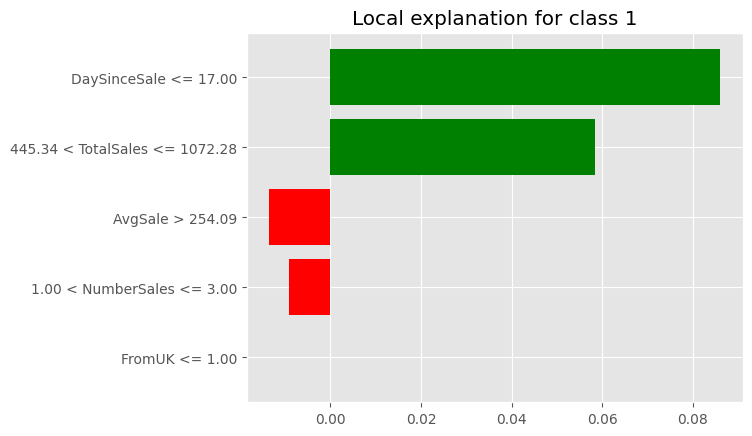

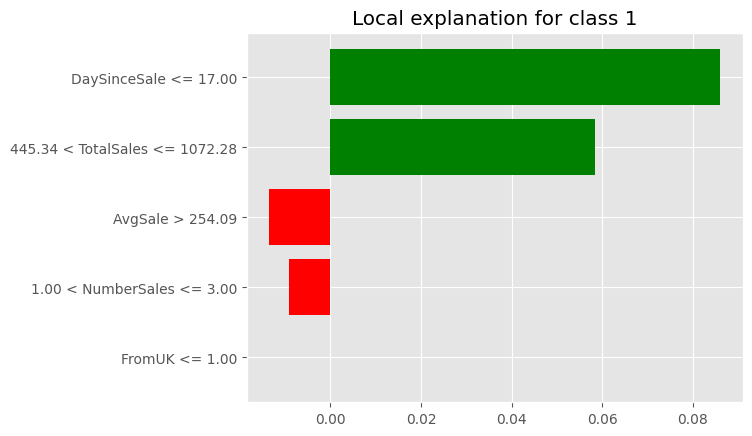

In [70]:
surrogate_prediction = explicador.predict_surrogate(X.loc[1], mode='classification')
surrogate_prediction.as_pyplot_figure()

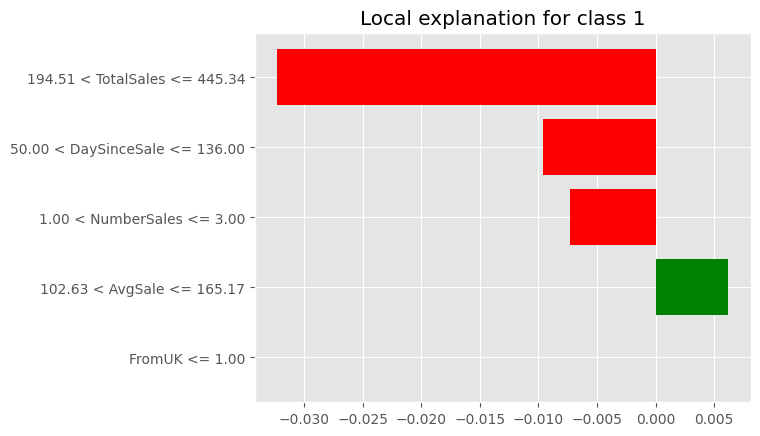

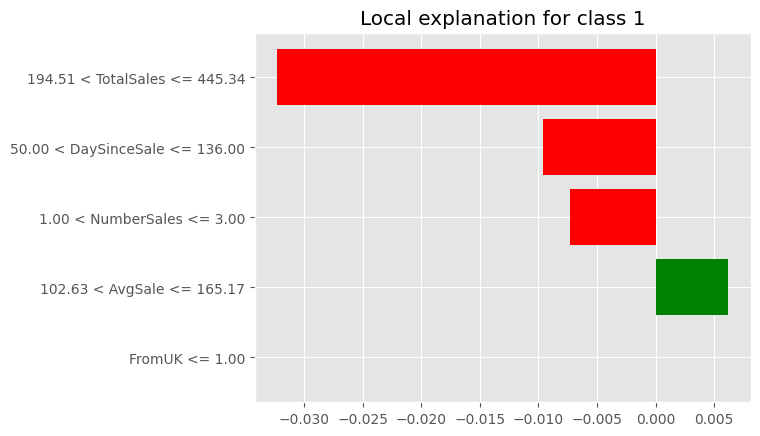

In [71]:
surrogate_prediction = explicador.predict_surrogate(X.loc[65], mode='classification')
surrogate_prediction.as_pyplot_figure()

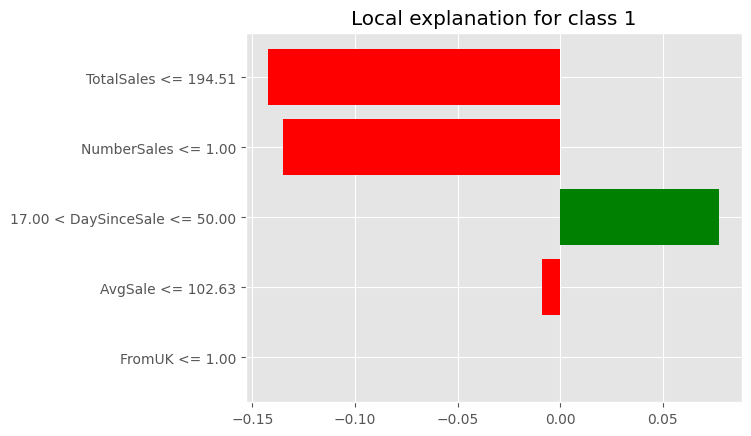

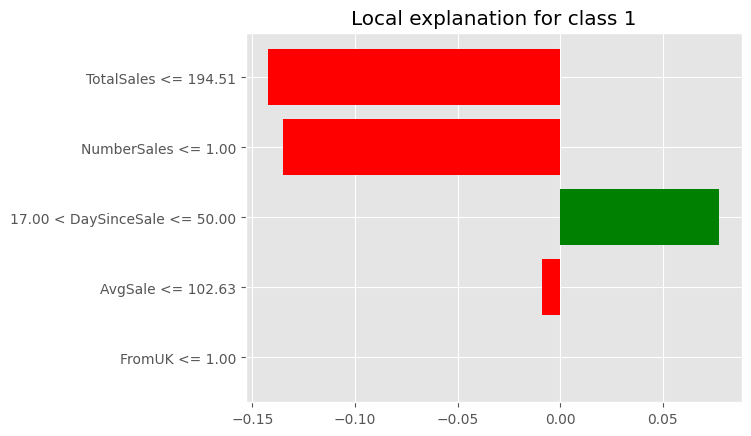

In [72]:
surrogate_prediction = explicador.predict_surrogate(X.loc[387], mode='classification')
surrogate_prediction.as_pyplot_figure()